### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
import os
import astropy.convolution as krn
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

from deepeye_analysis_package.plotting import makeHeat

In [2]:
def compute_rms(samples):
    # Assuming `samples` is a list of tuples, each containing (x, y) coordinates
    deltas = np.diff(samples, axis=0)
    distances = np.linalg.norm(deltas, axis=1)
    rms = np.sqrt(np.mean(distances**2))
    return rms

### Preprocess files and make a dataframe

test_all file contains the results of a validation session. If calibration had to be repeated under the same participant name, then the results of the new validation are appended. Therefore, the test_all file may contain several validation datasets, each with each own header row. 


1. get_last_dataset()
    Extract the last dataset from the test_all file based on the header row. Participants had 3 attempts to get calibration <3 cm. Keep only the successful calibration dataset
2. scale_dot_postion()
    Scale pixels to standard dimensions. Calibration dots were presented as % display size in px. Convert pixels to cm. Assign each dot a unique label



In [3]:
def get_last_dataset(df):
   
    # Define numeric columns for conversion to number
    numeric_columns = ['numCalibDots', 'x', 'y', 'user_pred_px_x', 'user_pred_px_y', 'scrW_cm', 'resX', 'resY']    

    # Identify duplicate rows, which likely represent header rows
    header_indices = df.index[df.duplicated(keep=False)].tolist()

    # Extract the dataset after the last duplicated header, if any
    if header_indices:
        last_dataset = df.iloc[header_indices[-1]:].reset_index(drop=True)
        last_dataset.columns = last_dataset.iloc[0]  # Set column names from the first row after the header
        last_dataset = last_dataset[1:]  # Remove header row
    else:
        # If no additional headers, use the entire dataset with the first row as column names
        last_dataset = df
        last_dataset.columns = last_dataset.iloc[0]
        last_dataset = last_dataset[1:]

    # Reset column headers and convert specified columns to numeric, coercing errors
    last_dataset = last_dataset.reset_index(drop=True)
    last_dataset[numeric_columns] = last_dataset[numeric_columns].apply(pd.to_numeric, errors='coerce')

    # Drop rows where 'numCalibDots' is NaN and convert to integer
    last_dataset.dropna(subset=['numCalibDots'], inplace=True)
    last_dataset['numCalibDots'] = last_dataset['numCalibDots'].astype(int)
    

    # Calculate Euclidean distance in pixels and centimeters
    last_dataset['eucl_dist_px_orig'] = np.linalg.norm(
        last_dataset[['x', 'y']].to_numpy() - last_dataset[['user_pred_px_x', 'user_pred_px_y']].to_numpy(), axis=1
    )
    
    # Get scaling factor for converting to px to cm    
    last_dataset['scale_cm_in_px'] = last_dataset['scrW_cm'] / last_dataset['resX']
    last_dataset['eucl_dist_cm_orig'] = last_dataset['eucl_dist_px_orig'] * last_dataset['scale_cm_in_px']
    

    return last_dataset

In [4]:
def get_second_to_last_dataset(df):
    # Define numeric columns for conversion to number
    numeric_columns = ['numCalibDots', 'x', 'y', 'user_pred_px_x', 'user_pred_px_y', 'scrW_cm', 'resX', 'resY']    

    # Identify duplicate rows, which likely represent header rows
    header_indices = df.index[df.duplicated(keep=False)].tolist()

    # Extract the dataset before the last duplicated header, if any
    if len(header_indices) > 1:
        # Get the range between the second to last and last header
        second_last_start = header_indices[-2]
        last_start = header_indices[-1]
        second_to_last_dataset = df.iloc[second_last_start:last_start].reset_index(drop=True)
        second_to_last_dataset.columns = second_to_last_dataset.iloc[0]  # Set column names from the first row after the header
        second_to_last_dataset = second_to_last_dataset[1:]  # Remove header row
    else:
        # If no additional headers, use the entire dataset with the first row as column names
        second_to_last_dataset = df
        second_to_last_dataset.columns = second_to_last_dataset.iloc[0]
        second_to_last_dataset = second_to_last_dataset[1:]

    # Reset column headers and convert specified columns to numeric, coercing errors
    second_to_last_dataset = second_to_last_dataset.reset_index(drop=True)
    second_to_last_dataset[numeric_columns] = second_to_last_dataset[numeric_columns].apply(pd.to_numeric, errors='coerce')

    # Drop rows where 'numCalibDots' is NaN and convert to integer
    second_to_last_dataset.dropna(subset=['numCalibDots'], inplace=True)
    second_to_last_dataset['numCalibDots'] = second_to_last_dataset['numCalibDots'].astype(int)
    
    # Calculate Euclidean distance in pixels and centimeters
    second_to_last_dataset['eucl_dist_px_orig'] = np.linalg.norm(
        second_to_last_dataset[['x', 'y']].to_numpy() - second_to_last_dataset[['user_pred_px_x', 'user_pred_px_y']].to_numpy(), axis=1
    )
    
    # Get scaling factor for converting to px to cm    
    second_to_last_dataset['scale_cm_in_px'] = second_to_last_dataset['scrW_cm'] / second_to_last_dataset['resX']
    second_to_last_dataset['eucl_dist_cm_orig'] = second_to_last_dataset['eucl_dist_px_orig'] * second_to_last_dataset['scale_cm_in_px']
    
    return second_to_last_dataset

In [5]:
def scale_dot_position(last_dataset, fn, target_resX=None, target_resY=None):

    # Define target resolution for scaling not provided, take the first resolution in the dataset
    if not target_resX or not target_resY:
        target_resX, target_resY = last_dataset['resX'].iloc[0], last_dataset['resY'].iloc[0]

    # Scale coordinates
    last_dataset['user_pred_px_x_scaled'] = last_dataset['user_pred_px_x'] / last_dataset['resX'] * target_resX
    last_dataset['user_pred_px_y_scaled'] = last_dataset['user_pred_px_y'] / last_dataset['resY'] * target_resY
    last_dataset['x_scaled'] = np.round(last_dataset['x'] / last_dataset['resX'] * target_resX)
    last_dataset['y_scaled'] = np.round(last_dataset['y'] / last_dataset['resY'] * target_resY)

    # Since the number of pixels changed after scaling to the same spaces, we need to recompute the scaling factor
    # This is only used for plotting overall heatmap
    last_dataset['new_scale_cm_in_px'] = last_dataset['scrW_cm'] / target_resX

    # Add subject identifier
    last_dataset['subj_nr'] = fn

    # Identify unique dot positions
    _, indices = np.unique(last_dataset[['x_scaled', 'y_scaled']], axis=0, return_inverse=True)
    last_dataset['unique_dot'] = indices

    return last_dataset


In [6]:
# Path to data folders
path_to_folders = r'C:/Users/aby600/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer/MullerLyer_online/complete/data'
# path_to_folders = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_MullerLyer//MullerLyer_online/complete/data'

# Get all folder names
folder_names = os.listdir(path_to_folders)

# List to accumulate datasets across subjects
pp_list = []

# Define target resolution, since datasets may have different screen resolutions
TARG_RES = True
if TARG_RES:
    target_resX, target_resY = 1920, 1080
else:
    target_resX, target_resY = None, None

for fn in folder_names:
    path = os.path.join(path_to_folders, fn, f"{fn}_test_all.csv")
    
    try:
        # Read the file into a DataFrame without assuming headers
        df = pd.read_csv(path, header=None)        
    except Exception:
        continue

    df = get_second_to_last_dataset(df)
    df = df.drop_duplicates(subset=['user_pred_px_x', 'user_pred_px_y'], ignore_index=True)  # Ensure unique coordinates (sometimes webcam is stuck)
    df = scale_dot_position(df, fn, target_resX, target_resY)

    # Identify unique dot positions
    unique_dots = df[['x_scaled', 'y_scaled']].drop_duplicates()

    # Filter out participants if they have fewer unique dots than the number in 'numCalibDots'
    required_dots = df['numCalibDots'].iloc[0]
    if len(unique_dots) < required_dots:
        print(f"Skipping participant {fn} with fewer unique dots ({len(unique_dots)}) than required ({required_dots})")
        continue  # Skip this participant if they have fewer unique dots

    # Append the cleaned dataset to the list
    pp_list.append(df)

# Concatenate all subject data into a single DataFrame
all_df = pd.concat(pp_list, ignore_index=True)

Skipping participant 2024_11_24_12_57_58 with fewer unique dots (8) than required (9)


## Plot heatmap across all subjects

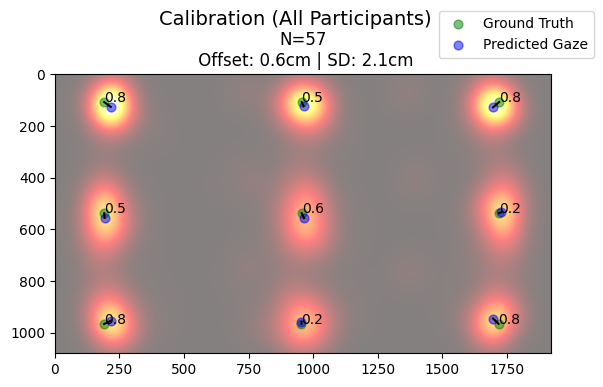

In [7]:
def plot_heatmap(df, target_resX, target_resY):
    # Generate heatmap for all gaze points
    heatmap = makeHeat([target_resX, target_resY], df['user_pred_px_x_scaled'].values, df['user_pred_px_y_scaled'].values)
    
    # Calculate median gaze predictions and ground truth per dot
    median_pred = df.groupby('unique_dot')[['user_pred_px_x_scaled', 'user_pred_px_y_scaled']].median()
    median_pred.columns = ['median_pred_x', 'median_pred_y']
    
    true_pos = df.groupby('unique_dot')[['x_scaled', 'y_scaled']].mean()
    
    # Calculate offset between median gaze predictions and ground truth, then convert to cm
    offset_px = np.linalg.norm(median_pred.values - true_pos.values, axis=1)
    # new scaling factor is used to convert px to cm for scaled data
    offset_cm = offset_px * df['new_scale_cm_in_px'].iloc[0]
    
    # Calculate Euclidean distance from each gaze point to the median prediction for each dot
    df = df.merge(median_pred, on='unique_dot', how='left')

    df['eucl_dist_gaze_to_median_px'] = np.linalg.norm(
        df[['user_pred_px_x_scaled', 'user_pred_px_y_scaled']].values - df[['median_pred_x', 'median_pred_y']].values,
        axis=1
    )    
    
    # Calculate the mean Euclidean distance per dot and convert to cm for standard deviation (SD)
    SD_px = df.groupby('unique_dot')['eucl_dist_gaze_to_median_px'].mean()
    # new scaling factor is used to convert px to cm for scaled data
    SD_cm = SD_px * df['new_scale_cm_in_px'].iloc[0]

    # Plot heatmap and ground truth vs. predicted gaze points
    plt.figure()
    plt.imshow(heatmap, cmap=cm.hot, extent=[0, target_resX, target_resY, 0], alpha=0.5, aspect='equal')
    
    # Plot ground truth positions (green) and median predicted gaze (blue)
    plt.scatter(true_pos['x_scaled'], true_pos['y_scaled'], c='g', s=40, alpha=0.5, label='Ground Truth')
    plt.scatter(median_pred['median_pred_x'], median_pred['median_pred_y'], c='b', s=40, alpha=0.5, label='Predicted Gaze')
    
    # Draw lines between ground truth and predictions for visualizing offsets
    plt.plot([median_pred['median_pred_x'], true_pos['x_scaled']], [median_pred['median_pred_y'], true_pos['y_scaled']], c='black')
            
    # Title and statistics in the legend
    plt.title(f'N={df["subj_nr"].nunique()}\n Offset: {offset_cm.mean():.1f}cm | SD: {SD_cm.mean():.1f}cm', fontsize=12)
    
    # Annotate offset values near each ground truth dot position
    for (x, y, e) in zip(true_pos['x_scaled'], true_pos['y_scaled'], offset_cm.round(1)):
        plt.text(x, y, str(e), fontsize=10, color='black')
    
    # Add legend and final touches
    plt.suptitle('Calibration (All Participants)', fontsize=14)
    plt.subplots_adjust(top=1.0)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.25))
    
    # Show the plot
    plt.show()

# Call the function with the dataframe
plot_heatmap(all_df, target_resX, target_resY)


## Calculate and plot offsets and SD per condition per subject

1. Offset - euclidean distance from the median gaze prediction per each dot to the ground truth
2. SD - mean of euclidean distances from each gaze prediction to the median gaze prediction for each dot
3. RMS - sample to sample euclidean distance for each gaze positions for each dot

In [8]:
# Prepare summary data across subjects
summary_data = []

# Calculate metrics for each subject and unique dot
for _, group in all_df.groupby(['subj_nr', 'unique_dot']):
    # Compute median gaze for each unique dot
    median_x = group['user_pred_px_x_scaled'].median()
    median_y = group['user_pred_px_y_scaled'].median()
    
    # Sort by timestamp to ensure temporal order
    group.sort_values('frameNr', inplace=True)    

    # Compute Euclidean distances
    gaze_coords = group[['user_pred_px_x_scaled', 'user_pred_px_y_scaled']].to_numpy()
    median_coords = np.array([median_x, median_y])
    
    # Distance from gaze samples to median gaze (precision)
    group['eucl_dist_gaze_to_median_px'] = np.linalg.norm(gaze_coords - median_coords, axis=1)
    group['eucl_dist_gaze_to_median_cm'] = group['eucl_dist_gaze_to_median_px'] * all_df['scale_cm_in_px'].iloc[0]
    
    # Offset from median gaze to ground truth (accuracy)
    ground_truth_coords = group[['x_scaled', 'y_scaled']].to_numpy()
    group['median_offset_px'] = np.linalg.norm(median_coords - ground_truth_coords, axis=1)
    group['median_offset_cm'] = group['median_offset_px'] * all_df['scale_cm_in_px'].iloc[0]

    # RMS error sample-to-sample (temproal precision)
    group['rms_error_px'] = compute_rms(gaze_coords)
    group['rms_error_cm'] = group['rms_error_px'] * all_df['scale_cm_in_px'].iloc[0]
    
    summary_data.append(group)

# Combine data across all subjects and calculate mean precision (SD) and accuracy (offset)
summary_df = pd.concat(summary_data)

c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aby600\Documents\GitHub\DeepEye_analyze\deepeye_analyze\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


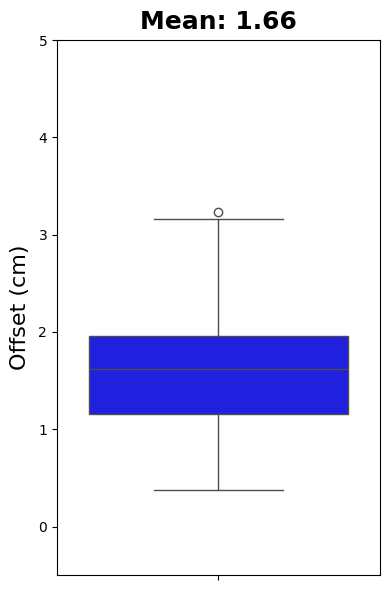

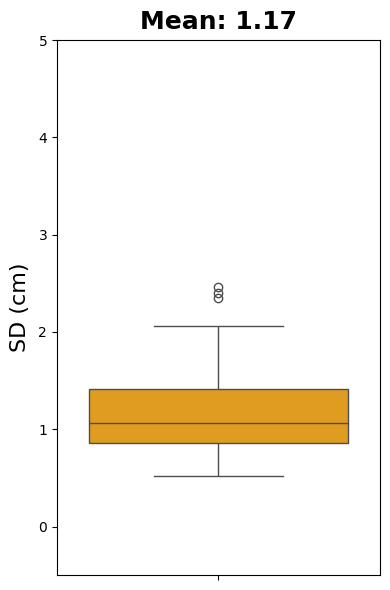

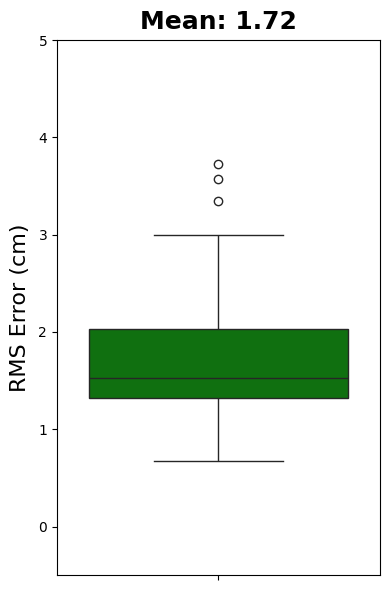

In [9]:
def plot_measurement_per_participant(df, measurement='median_offset_cm', name='', color='b'):
    # Compact figure for matching inset plot style
    fig, ax = plt.subplots(figsize=(4, 6))  # Smaller size for side-by-side presentation

    # Calculate measurement per participant and mean value
    measurement_pp = df.groupby('subj_nr', as_index=False)[measurement].mean()
    mean_value = measurement_pp[measurement].mean()

    # Simplified box plot to match inset style
    sns.boxplot(y=measurement_pp[measurement], ax=ax, color=color)
    # sns.rugplot(y=measurement_pp[measurement], ax=ax, height=0.05, color=color)
    # ax.axhline(mean_value, color='k', linestyle='--', linewidth=1.5, label=f'Mean: {mean_value:.2f}')
    
    # Set y-axis limits and label
    ax.set_ylim(-0.5, 5)
    ax.set_ylabel(f'{name}', fontsize=16, labelpad=6)
    ax.tick_params(axis='both', labelsize=10)
    
    # Simplify layout: remove x-axis label and set title within the plot
    ax.set_xlabel('')
    ax.set_title(f'Mean: {mean_value:.2f}', fontsize=18, weight='bold', pad=8)
    
    # Compact layout adjustments
    fig.tight_layout()
    plt.show()

    # Uncomment the line below to save the plot
    # fig.savefig(f'{name}_summary.jpg', dpi=1000)


summary_df_per_pp= summary_df.groupby(['subj_nr'])[['median_offset_cm', 'eucl_dist_gaze_to_median_cm', 'rms_error_cm']].mean().reset_index()

plot_measurement_per_participant(summary_df_per_pp, measurement='median_offset_cm', name='Offset (cm)', color='b')
plot_measurement_per_participant(summary_df_per_pp, measurement='eucl_dist_gaze_to_median_cm', name='SD (cm)', color='orange')
plot_measurement_per_participant(summary_df_per_pp, measurement='rms_error_cm', name='RMS Error (cm)', color='g')

In [10]:
# Participant descriptive statistics (gaze samples per participant)
descr_stats = summary_df.groupby(['subj_nr', 'pp_id'])['unique_dot'].count().reset_index()
print(f'Descriptive Stats:\n {descr_stats}')

Descriptive Stats:
                 subj_nr                     pp_id  unique_dot
0   2024_11_20_14_07_16  670d749686d3bb0c4620a28e         364
1   2024_11_20_15_51_08  628781515f29a0394e23b15b         393
2   2024_11_20_16_04_05  65269d7fc5cc43e77f02d75d         189
3   2024_11_20_16_52_32  5f61023f891bb903b975dbee         398
4   2024_11_20_17_28_10  6724d4dc0e4e106b64f4dd4b         285
5   2024_11_20_18_37_11  6658c5cc20f33b713aa2592d         140
6   2024_11_20_19_28_30  6724d4dc0e4e106b64f4dd4b         254
7   2024_11_20_20_12_55  6739346d4a955c4361e80246         362
8   2024_11_20_20_51_26  6733ab090f7aff5453ad5a65         363
9   2024_11_20_21_38_28  6022d09061828908fbf92853         104
10  2024_11_20_22_31_32  672943f01665b053c5cd5c86         358
11  2024_11_20_23_14_07  66d5ae2f15efe961e36cd38c         244
12  2024_11_20_23_31_23  6730f29e631dc6f07f4621f8         409
13  2024_11_21_00_05_36  66be6285f4576f824813e7e8         216
14  2024_11_21_00_39_02  62b44f66a16d45783569fad6 

In [11]:
# Participant descriptive statistics (gaze samples per participant)
descr_stats2 = summary_df.groupby(['subj_nr','unique_dot'])['median_offset_cm'].count().reset_index()
descr_stats3 = descr_stats2.groupby(['subj_nr']).unique_dot.count().reset_index()
print(f'Mean unique dots:\n {descr_stats3}')

Mean unique dots:
                 subj_nr  unique_dot
0   2024_11_20_14_07_16           9
1   2024_11_20_15_51_08           9
2   2024_11_20_16_04_05           9
3   2024_11_20_16_52_32           9
4   2024_11_20_17_28_10           9
5   2024_11_20_18_37_11           9
6   2024_11_20_19_28_30           9
7   2024_11_20_20_12_55           9
8   2024_11_20_20_51_26           9
9   2024_11_20_21_38_28           9
10  2024_11_20_22_31_32           9
11  2024_11_20_23_14_07           9
12  2024_11_20_23_31_23           9
13  2024_11_21_00_05_36           9
14  2024_11_21_00_39_02           9
15  2024_11_21_00_59_21           9
16  2024_11_21_11_30_30           9
17  2024_11_21_11_51_28           9
18  2024_11_21_12_16_25           9
19  2024_11_21_13_04_06           9
20  2024_11_21_13_27_22           9
21  2024_11_21_14_07_55           9
22  2024_11_21_15_49_10           9
23  2024_11_21_17_27_02           9
24  2024_11_21_19_08_11           9
25  2024_11_21_19_57_14           9
26  2024_

## Plot offset per dot per subject

Maximum value: 7.963868534733046
Index of maximum value: 49


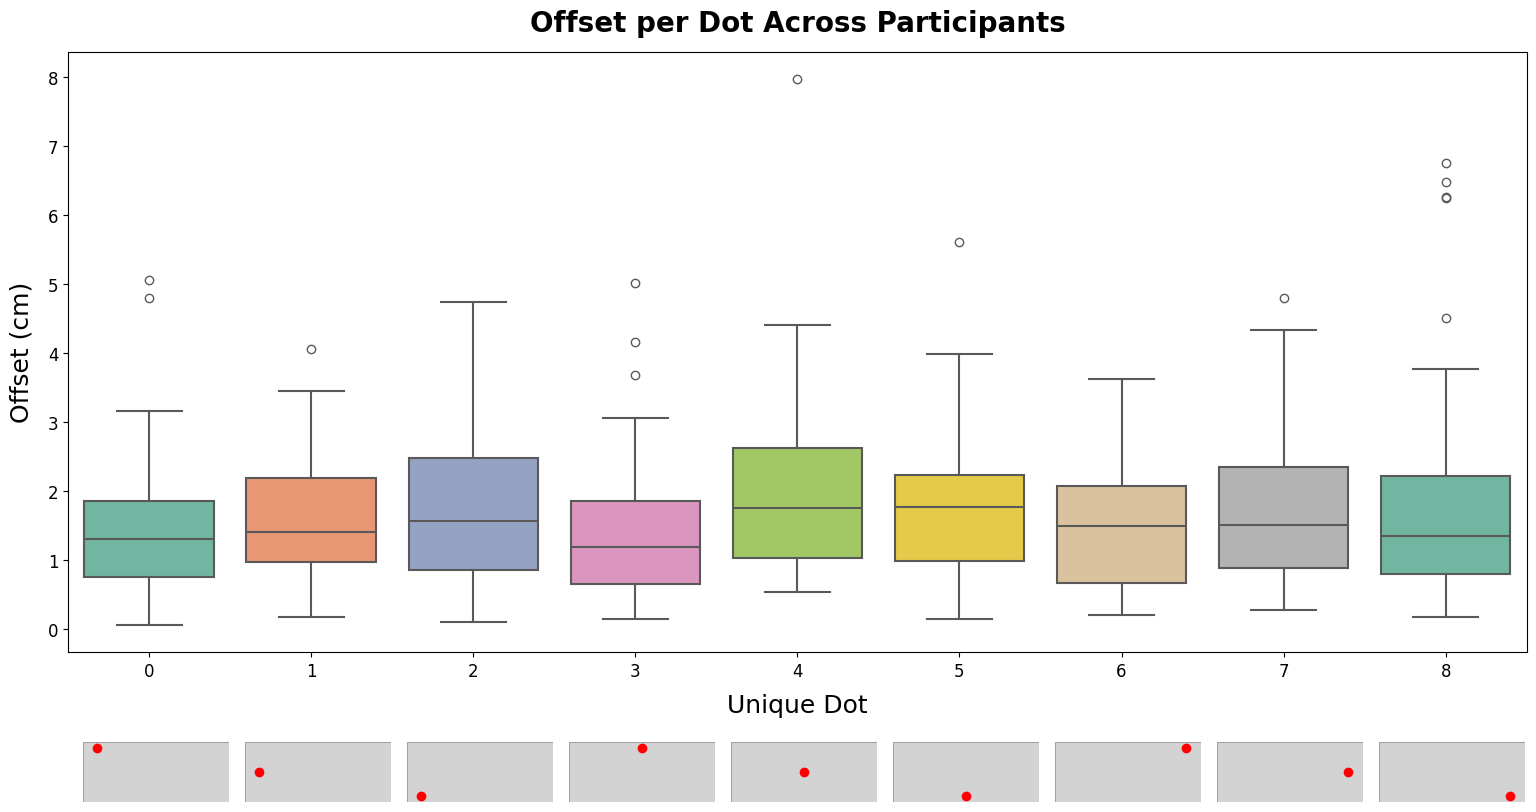

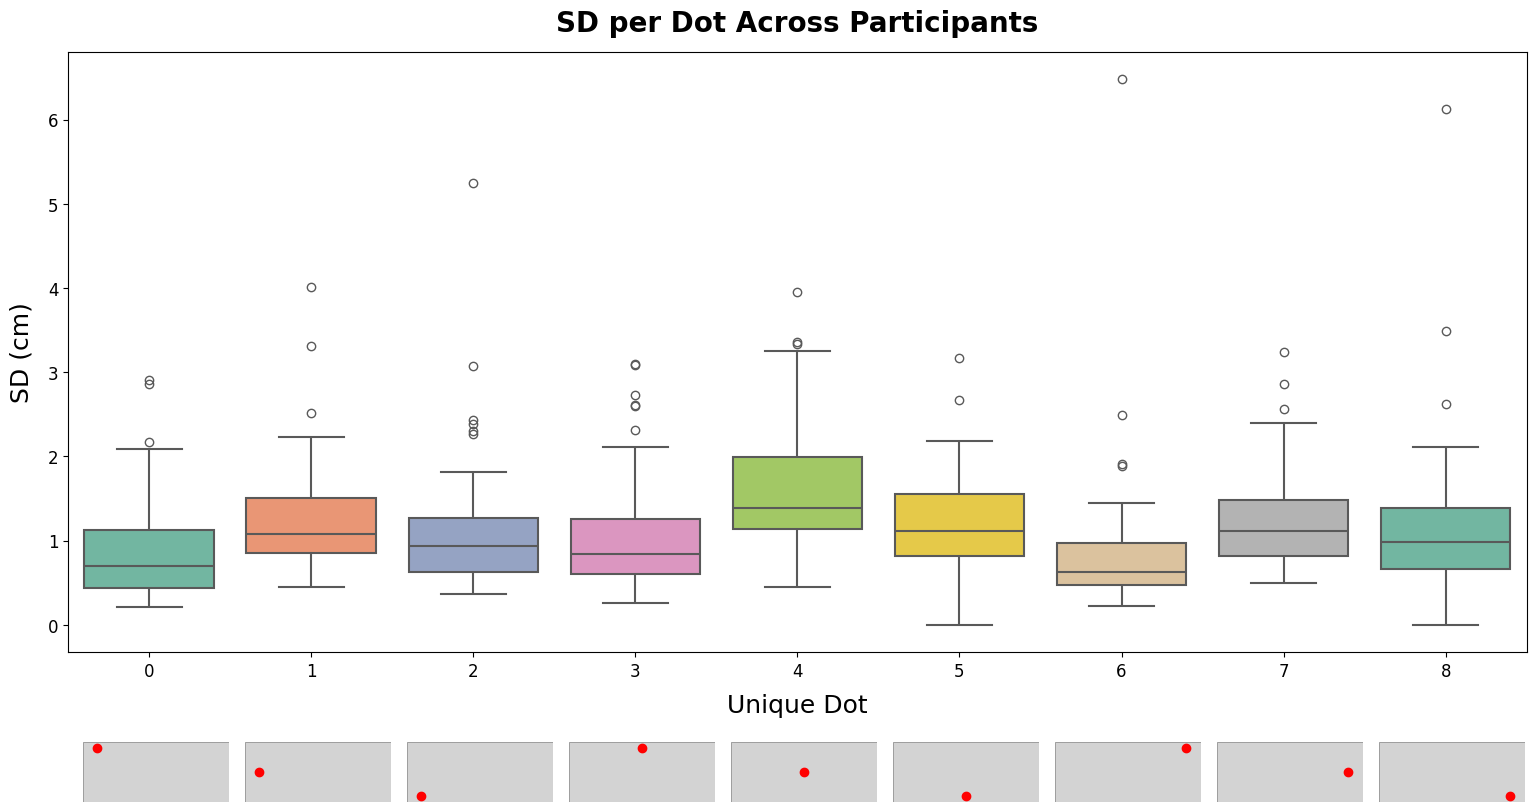

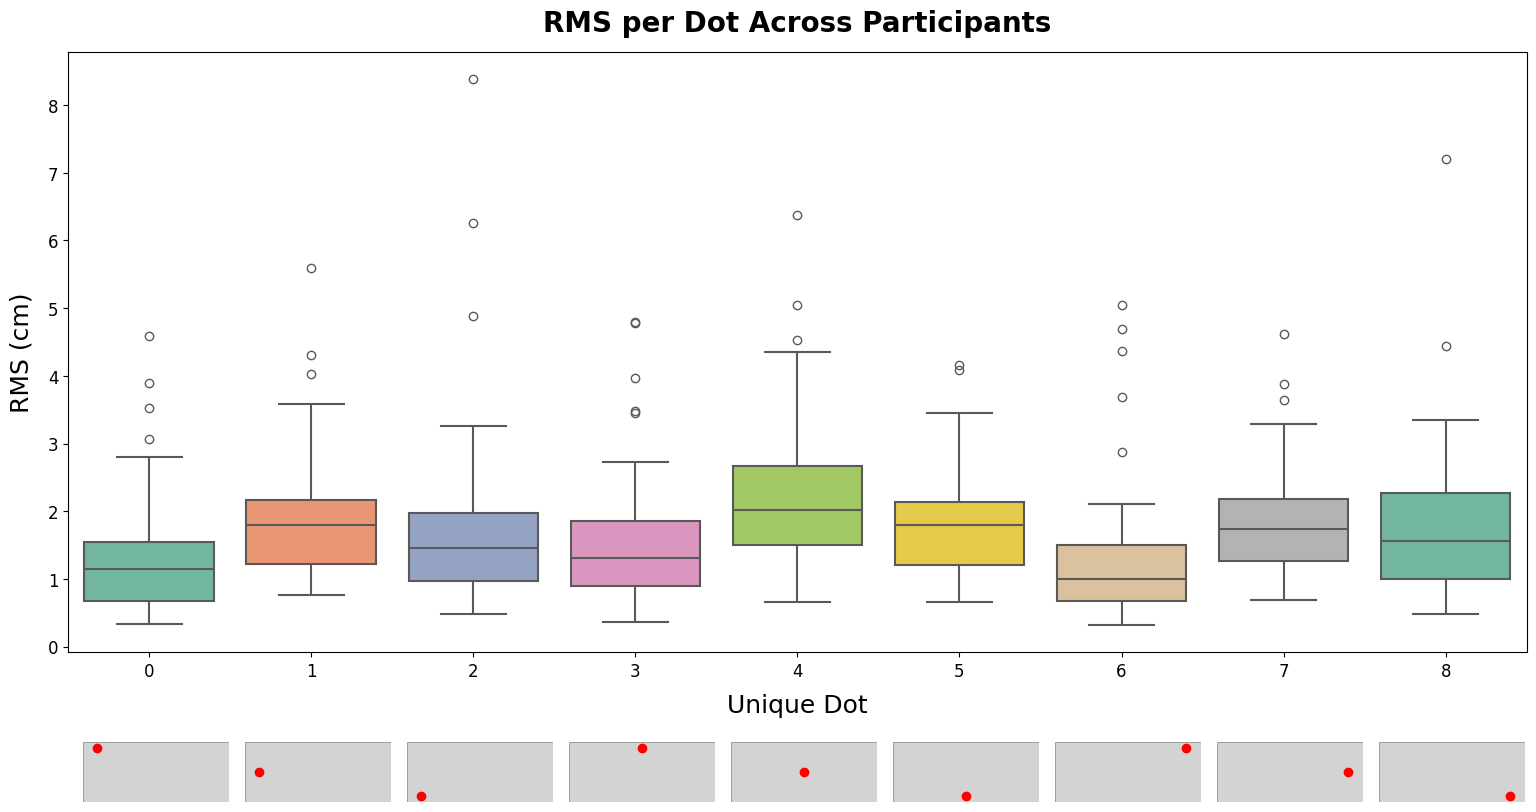

In [12]:
def plot_offset_per_dot_with_positions(summary_df, measurement='Offset', screen_width=192, screen_height=1080):
    """
    Plots offset across participants for each dot with a small illustration under each box plot
    indicating each dot's position on the screen.
    
    Parameters:
    - summary_df (pd.DataFrame): Dataframe containing offset data for each dot and participant.    
    - screen_width (int): Width of the screen (for relative positioning).
    - screen_height (int): Height of the screen (for relative positioning).
    """
    
    # Set up the main figure and the box plot
    plt.figure(figsize=(16, 10))  # Larger figure for readability
    main_ax = plt.gca()
    
    # Increase font sizes for labels, ticks, and title
    main_ax.set_xlabel('Unique Dot', fontsize=18, labelpad=10)
    main_ax.set_ylabel(f'{measurement} (cm)', fontsize=18, labelpad=10)
    main_ax.set_title(f'{measurement} per Dot Across Participants', fontsize=20, weight='bold', pad=15)
    main_ax.tick_params(axis='both', labelsize=12)
    
    # Set y-ticks for clearer reading
    plt.yticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    
    # Box plot with enhanced appearance
    palette = sns.color_palette("Set2", len(summary_df['unique_dot'].unique()))
    if measurement == 'Offset':
        sns.boxplot(x='unique_dot', y='median_offset_cm', data=summary_df, hue='unique_dot', palette=palette, ax=main_ax, linewidth=1.5)
    elif measurement == 'SD':
        sns.boxplot(x='unique_dot', y='eucl_dist_gaze_to_median_cm', data=summary_df, hue='unique_dot', palette=palette, ax=main_ax, linewidth=1.5)
    elif measurement == 'RMS':
        sns.boxplot(x='unique_dot', y='rms_error_cm', data=summary_df, hue='unique_dot', palette=palette, ax=main_ax, linewidth=1.5)
    
    main_ax.get_legend().remove()  # Remove legend if unnecessary

    # Draw small position illustrations below each unique dot box
    unique_dots = summary_df['unique_dot'].unique()
    for i, dot in enumerate(unique_dots):
        dot_data = summary_df[summary_df['unique_dot'] == dot]
        x_avg = dot_data['x_scaled'].mean()
        y_avg = dot_data['y_scaled'].mean()
        
        # Define inset axes positions for more space
        inset_ax = main_ax.inset_axes([i / len(unique_dots) + 0.01, -0.25, 0.9 / len(unique_dots), 0.1])
        
        # Draw rectangle and plot dot’s position
        inset_ax.add_patch(patches.Rectangle((0, 0), screen_width, screen_height, edgecolor='gray', facecolor='lightgray', linewidth=0.5))
        inset_ax.plot(x_avg / 1920 * screen_width, y_avg / 1080 * screen_height, 'ro', markersize=6)
        
        # Customize the inset plot appearance
        inset_ax.set_xlim(0, screen_width)
        inset_ax.set_ylim(0, screen_height)
        inset_ax.invert_yaxis()
        inset_ax.axis('off')  # Hide inset plot axes for clarity

    # Layout adjustments for clarity
    plt.tight_layout(pad=3)
    plt.subplots_adjust(top=0.85, bottom=0.25)
    plt.show()

# Example usage:
# plot_offset_per_dot_with_positions(summary_df, measurement='Offset', screen_width=192, screen_height=1080)


summary_df_per_dot= summary_df.groupby(['subj_nr','unique_dot', 'x_scaled', 'y_scaled'])[['median_offset_cm', 'eucl_dist_gaze_to_median_cm', 'rms_error_cm']].mean().reset_index()
max_value = summary_df_per_dot['median_offset_cm'].max()
max_index = summary_df_per_dot['median_offset_cm'].idxmax()
print("Maximum value:", max_value)
print("Index of maximum value:", max_index)

plot_offset_per_dot_with_positions(summary_df_per_dot, measurement='Offset')
plot_offset_per_dot_with_positions(summary_df_per_dot, measurement='SD')
plot_offset_per_dot_with_positions(summary_df_per_dot, measurement='RMS')

In [13]:
# Group dots by the column and row they are in
_, col_indices = np.unique(summary_df_per_dot[['x_scaled']], axis=0, return_inverse=True)
summary_df_per_dot['unique_column'] = col_indices
_, row_indices = np.unique(summary_df_per_dot[['y_scaled']], axis=0, return_inverse=True)
summary_df_per_dot['unique_row'] = row_indices


In [14]:
# dot_rows = summary_df_per_dot.groupby(['subj_nr', 'unique_row'], as_index=False)['median_offset_cm'].mean()

# print(dot_rows.groupby(['unique_row']).median_offset_cm.mean())


# # Perform the repeated measures ANOVA
# anova = AnovaRM(dot_rows, depvar='median_offset_cm', subject='subj_nr', within=['unique_row']).fit()

# # Display the ANOVA table
# print(anova.summary())

# dot_columns = summary_df_per_dot.groupby(['subj_nr', 'unique_column'], as_index=False)['median_offset_cm'].mean()   

# print(dot_columns.groupby(['unique_column']).median_offset_cm.mean())

# # Perform the repeated measures ANOVA
# anova = AnovaRM(dot_columns, depvar='median_offset_cm', subject='subj_nr', within=['unique_column']).fit()

# # Display the ANOVA table
# print(anova.summary())

# import pingouin as pg

# # Perform pairwise comparisons with Bonferroni correction
# pairwise_results = pg.pairwise_tests(dv='median_offset_cm', within='unique_row', subject='subj_nr', 
#                                       data=dot_rows, padjust='bonf')

# # Display the results
# print(pairwise_results)



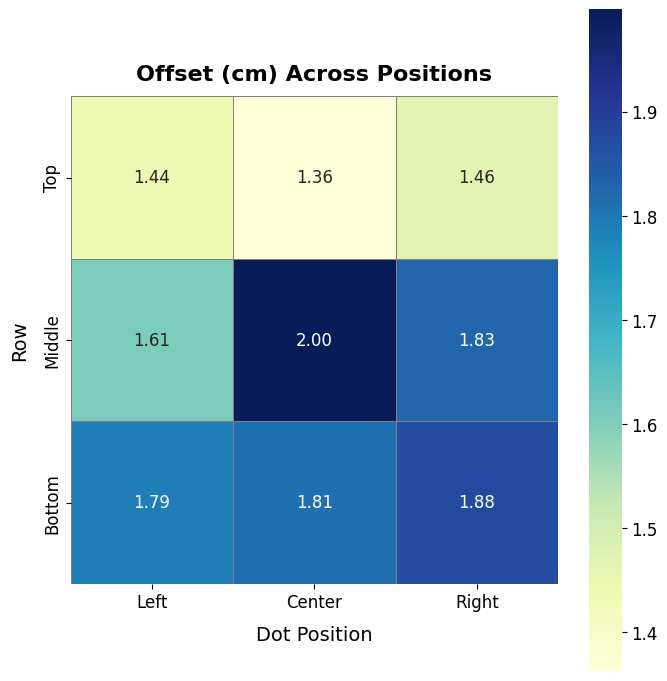

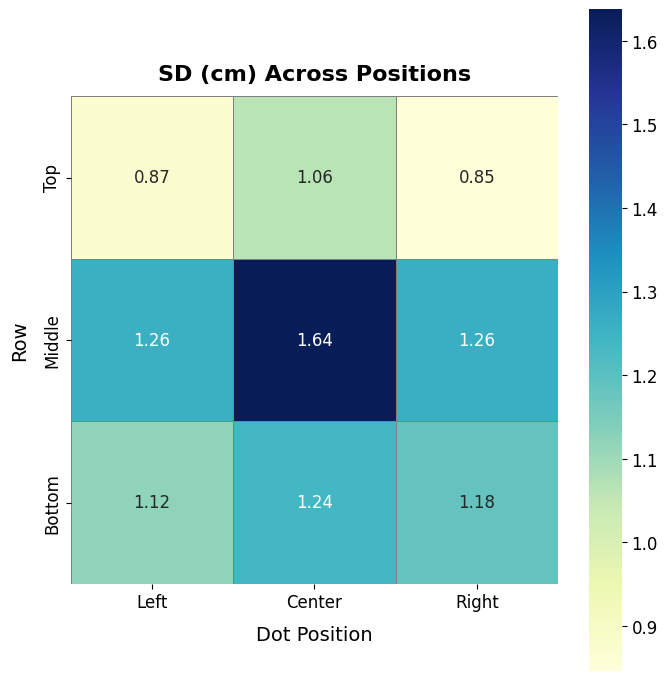

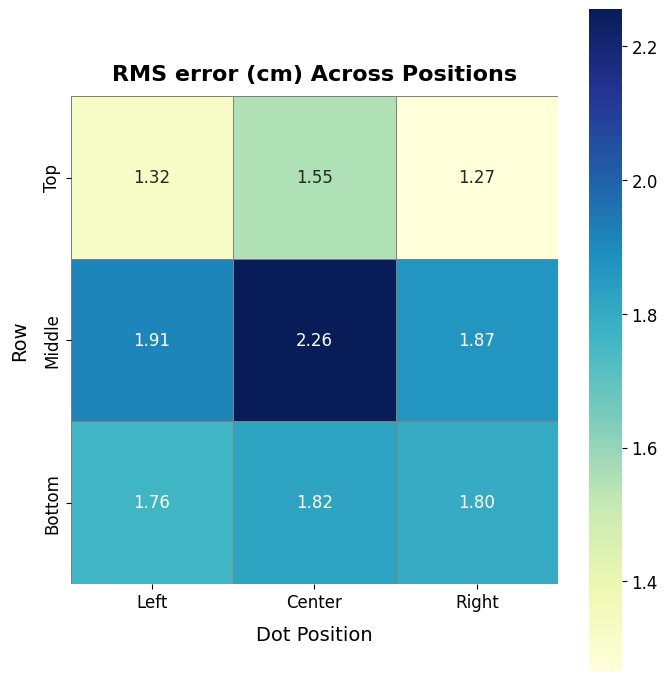

In [15]:
def plot_matrix(df, measurement='median_offset_cm', title='Average Median Offset Across Positions'):
    # Calculate the average median offset for each dot across all subjects
    average_per_dot = df.groupby('unique_dot', as_index=False)[measurement].mean()

    # Create a DataFrame to reflect the 3-row layout
    dot_matrix = pd.DataFrame({
        'Column 1': average_per_dot[measurement][0:3].values,
        'Column 2': average_per_dot[measurement][3:6].values,
        'Column 3': average_per_dot[measurement][6:9].values
    })
    
    # Set up the plot
    plt.figure(figsize=(7, 7))
    heatmap = sns.heatmap(dot_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                          square=True, annot_kws={"size": 12}, linewidths=0.5, linecolor='gray')
    
    # Customize title and labels for readability
    plt.title(title, fontsize=16, weight='bold', pad=12)
    plt.xlabel('Dot Position', fontsize=14, labelpad=10)
    plt.ylabel('Row', fontsize=14, labelpad=10)

    # Set tick labels for rows and columns for clarity
    heatmap.set_xticklabels(['Left', 'Center', 'Right'], fontsize=12)
    heatmap.set_yticklabels(['Top', 'Middle', 'Bottom'], fontsize=12)
    
    # Customize colorbar label size
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=12)
    
    # Adjust layout for a clean look
    plt.tight_layout()
    plt.show()

plot_matrix(summary_df_per_dot, measurement='median_offset_cm', title='Offset (cm) Across Positions')
plot_matrix(summary_df_per_dot, measurement='eucl_dist_gaze_to_median_cm', title='SD (cm) Across Positions')
plot_matrix(summary_df_per_dot, measurement='rms_error_cm', title='RMS error (cm) Across Positions')